# Домашнее задание №2: Полный цикл Разведочного анализа данных (EDA)
## Данные:
**Датасет содержит информацию о треках Spotify:**
- аудио характеристики (energy, danceability, tempo)
- популярность
- жанр
- исполнителя

**Техническое задание:**
1. Импорт библиотек
2. Загрузка данных
3. Быстрый обзор данных
4. Проверка качества данных
5. Работа с пропусками
6. Расширенная статистика
7. Feature Engineering
8. Encoding категорий
9. Визуализация
10. Выводы и гипотезы

Ссылка на датасет: https://www.kaggle.com/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features

In [1]:
!python -m venv medven
!medven\Scripts\pip install ipykernel
!medven\Scripts\python -m ipykernel install --user --name=medven --display-name "Python (medven)"


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\medve_sje3ihc\ML\medven\Scripts\python.exe -m pip install --upgrade pip


Installed kernelspec medven in C:\Users\medve_sje3ihc\AppData\Roaming\jupyter\kernels\medven


## A) Быстрый обзор данных (Pandas)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

In [4]:
# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('spotify-tracks-dataset-detailed.csv')

1. Загрузка данных


In [5]:
df.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.tail(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [8]:
df.shape

(114000, 20)

In [9]:
#Числовая статистика
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [10]:
#Статистика категориальных колонок
df.describe(include="object")

,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


In [11]:
#Проверка качества данных

In [12]:
#Пропуски
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [13]:
#Дубликаты
df.duplicated().sum()

450

In [14]:
df.dtypes

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

## B)Пропуски и очистка

In [15]:
print(df["tempo"].head())
print(df["tempo"].mean())
print(df["tempo"].isnull().sum())

0     87.917
1     77.489
2     76.332
3    181.740
4    119.949
Name: tempo, dtype: float64
122.14783728947369
0


In [16]:
#Заполнение средним
df["tempo"]=df["tempo"].fillna(df["tempo"].mean())

In [17]:
print(df["tempo"])

0          87.917
1          77.489
2          76.332
3         181.740
4         119.949
           ...   
113995    125.995
113996     85.239
113997    132.378
113998    135.960
113999     79.198
Name: tempo, Length: 114000, dtype: float64


In [18]:
print(df["tempo"].isnull().sum())

0


In [19]:
#Заполнение медианой
df["popularity"]=df["popularity"].fillna(df["popularity"].median())

In [20]:
print(df["popularity"])

0         73
1         55
2         57
3         71
4         82
          ..
113995    21
113996    22
113997    22
113998    41
113999    22
Name: popularity, Length: 114000, dtype: int64


In [21]:
print(df["popularity"].isnull().sum())

0


In [23]:
df.dropna()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [24]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [25]:
df.isna().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [138]:
#Подсчет моды
moda_art=df["artists"].mode()

In [135]:
print(moda_art)

0    The Beatles
Name: artists, dtype: object


In [27]:
df.mode()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,0.0,162897.0,False,0.647,0.876,7.0,-5.662,1.0,0.0323,0.995,0.0,0.108,0.961,0.0,4.0,acoustic
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,afrobeat
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,alt-rock
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,alternative
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,techno
110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,trance
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,trip-hop
112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,turkish


In [140]:
#Заполнение 
df["artists"].fillna(moda_art)

0                    Gen Hoshino
1                   Ben Woodward
2         Ingrid Michaelson;ZAYN
3                   Kina Grannis
4               Chord Overstreet
                   ...          
113995             Rainy Lullaby
113996             Rainy Lullaby
113997             Cesária Evora
113998          Michael W. Smith
113999             Cesária Evora
Name: artists, Length: 114000, dtype: object

In [29]:
print(moda_art)

0    The Beatles
Name: artists, dtype: object


//Среднее используется для числовых распределений.

//Медиана устойчива к выбросам.

//Мода подходит для категориальных признаков.

## C) Расширенная статистика

In [31]:
df["popularity"].min()


0

In [32]:
df["popularity"].max()


100

In [33]:
df["popularity"].mean()


33.2385350877193

In [34]:
df["popularity"].median()


35.0

In [35]:
df["popularity"].mode()

0    0
Name: popularity, dtype: int64

In [36]:
df["popularity"].quantile()

35.0

In [37]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[numeric_cols].quantile([0.5,0.05,0.75]))

      popularity  duration_ms  danceability  energy  key  loudness  mode  \
0.50        35.0     212906.0         0.580   0.685  5.0    -7.004   1.0   
0.05         0.0     116920.0         0.250   0.154  0.0   -18.067   0.0   
0.75        50.0     261506.0         0.695   0.854  8.0    -5.003   1.0   

      speechiness  acousticness  instrumentalness  liveness  valence  \
0.50       0.0489      0.169000          0.000042    0.1320   0.4640   
0.05       0.0282      0.000145          0.000000    0.0606   0.0708   
0.75       0.0845      0.598000          0.049000    0.2730   0.6830   

         tempo  time_signature  
0.50  122.0170             4.0  
0.05   77.3469             3.0  
0.75  140.0710             4.0  


In [38]:
df.var(numeric_only=True)

popularity          4.975165e+02
duration_ms         1.151280e+10
explicit            7.819044e-02
danceability        3.011689e-02
energy              6.326687e-02
key                 1.267351e+01
loudness            2.529423e+01
mode                2.310813e-01
speechiness         1.117933e-02
acousticness        1.105713e-01
instrumentalness    9.582420e-02
liveness            3.624367e-02
valence             6.721630e-02
tempo               8.986923e+02
time_signature      1.871608e-01
dtype: float64

In [39]:
#Дисперсия
df['tempo'].var()

898.6922905788324

In [40]:
#Ассиметрия
df.skew(numeric_only=True)

popularity           0.046403
duration_ms         11.195181
explicit             2.964731
danceability        -0.399497
energy              -0.597001
key                 -0.008500
loudness            -2.006542
mode                -0.572300
speechiness          4.647516
acousticness         0.727295
instrumentalness     1.734406
liveness             2.105738
valence              0.115078
tempo                0.232295
time_signature      -4.098317
dtype: float64

In [41]:
#Эксцесс
df.kurtosis(numeric_only=True)

popularity           -0.927755
duration_ms         354.952416
explicit              6.789751
danceability         -0.184502
energy               -0.525711
key                  -1.276571
loudness              5.896278
mode                 -1.672501
speechiness          28.824377
acousticness         -0.949931
instrumentalness      1.270747
liveness              4.378268
valence              -1.027430
tempo                -0.108581
time_signature       26.013238
dtype: float64

Variance — разброс данных.
Skewness — асимметрия распределения.
Kurtosis — наличие тяжёлых хвостов (выбросов).

## D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)

In [43]:
df["duration_min"] = df["duration_ms"] / 60000

In [44]:
df["energy_dance"] = df["energy"] * df["danceability"]

In [45]:
df["artists"].value_counts()

artists
The Beatles                                                                 279
George Jones                                                                271
Stevie Wonder                                                               236
Linkin Park                                                                 224
Ella Fitzgerald                                                             222
                                                                           ... 
Automatic Tasty                                                               1
o9                                                                            1
Pyotr Ilyich Tchaikovsky;National Philharmonic Orchestra;Richard Bonynge      1
tstewart;Ólafur Arnalds                                                       1
Jesus Culture                                                                 1
Name: count, Length: 31437, dtype: int64

In [46]:
rare = df["artists"].value_counts()[df["artists"].value_counts() < 2].index
print(rare)

Index(['František Sahula', 'Kevin Kendle', 'Tujamo;Kelvyn Colt',
       'Chris Thile;Michael Daves', 'Lane 8;Arctic Lake',
       'Andreas Vollenweider;Walter Keiser;Pedro Haldemann;Jon Otis;Matthias Ziegler;Christoph Ziegler',
       'Otto Knows;Avicii', 'Martin Garrix;Mike Yung', 'R3HAB;Amba Shepherd',
       'Giacomo Puccini;Luciano Pavarotti;National Philharmonic Orchestra;Nicola Rescigno',
       ...
       'Toronto Is Broken;Natty Campbell;Matt Neux',
       'Claude Debussy;Seong-Jin Cho', 'Erik Satie;Alice Sara Ott',
       'Pyotr Ilyich Tchaikovsky;Paris Conservatoire Orchestra;Anatole Fistoulari',
       'Claude Debussy;Jacques Février', 'Automatic Tasty', 'o9',
       'Pyotr Ilyich Tchaikovsky;National Philharmonic Orchestra;Richard Bonynge',
       'tstewart;Ólafur Arnalds', 'Jesus Culture'],
      dtype='object', name='artists', length=16767)


In [47]:
df["artists_grouped"] = df["artists"].replace(rare, "Other")

In [48]:
df["artists_grouped"].value_counts()

artists_grouped
Other                                          16767
The Beatles                                      279
George Jones                                     271
Stevie Wonder                                    236
Linkin Park                                      224
                                               ...  
El Alfa;Chael Produciendo;CJ;El Cherry Scom        2
dandelion hands                                    2
Midtown                                            2
brakence;blackbear                                 2
Meditación: Por Mateo;Meditaciónessa               2
Name: count, Length: 14671, dtype: int64

In [49]:
df_encoded = pd.get_dummies(df, columns=["artists_grouped"])

In [50]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,energy_dance,artists_grouped
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433,0.311636,Gen Hoshino
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500,0.069720,Ben Woodward
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767,0.157242,Other
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550,0.015854,Kina Grannis
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217,0.273774,Chord Overstreet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,6.416650,0.040420,Rainy Lullaby
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,6.416667,0.020358,Rainy Lullaby
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,4.524433,0.206941,Cesária Evora
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,4.731550,0.297022,Michael W. Smith


In [51]:
df['track_genre']

0            acoustic
1            acoustic
2            acoustic
3            acoustic
4            acoustic
             ...     
113995    world-music
113996    world-music
113997    world-music
113998    world-music
113999    world-music
Name: track_genre, Length: 114000, dtype: object

In [52]:
#Кодирование категорий (One Hot Encoding)
df_enc=pd.get_dummies(df,columns=['track_genre'])


In [53]:
print(df_enc);

                      track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                          To Begin Again   
3       Crazy Rich Asians (Original Motion Picture Sou...  

In [54]:
df[["track_genre"]].head()

,track_genre
0,acoustic
1,acoustic
2,acoustic
3,acoustic
4,acoustic


In [55]:
df_encoded = pd.get_dummies(df, columns=["track_genre"], drop_first=True)

df_encoded.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,energy_dance,artists_grouped,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,3.844433,0.311636,Gen Hoshino,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,2.493500,0.069720,Ben Woodward,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [56]:
#Порядковое кодирование (Label encoding)
#Когда категорий немного
df[["track_genre"]].head()

,track_genre
0,acoustic
1,acoustic
2,acoustic
3,acoustic
4,acoustic


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["genre_label"] = le.fit_transform(df["track_genre"])

In [58]:
df[["track_genre","genre_label"]].head()

,track_genre,genre_label
0,acoustic,0
1,acoustic,0
2,acoustic,0
3,acoustic,0
4,acoustic,0


In [59]:
df[["track_genre","genre_label"]].tail()

,track_genre,genre_label
113995,world-music,113
113996,world-music,113
113997,world-music,113
113998,world-music,113
113999,world-music,113


In [60]:
df[["track_genre","popularity"]].head()

,track_genre,popularity
0,acoustic,73
1,acoustic,55
2,acoustic,57
3,acoustic,71
4,acoustic,82


In [61]:
#Target больше для предсказаний
target_encoding = df.groupby("track_genre")["popularity"].mean()

df["genre_target_encoded"] = df["track_genre"].map(target_encoding)

In [62]:
df[["track_genre","genre_target_encoded"]].head()

,track_genre,genre_target_encoded
0,acoustic,42.483
1,acoustic,42.483
2,acoustic,42.483
3,acoustic,42.483
4,acoustic,42.483


In [63]:
#Применяет математическую функцию (хеш) к категории и распределяет ее в фиксированное число колонок.
#Feature Hashing
!pip install -U scikit-learn category_encoders

In [64]:
import category_encoders as ce

hash_encoder = ce.HashingEncoder(cols=["artists"], n_components=8)

df_hash = hash_encoder.fit_transform(df)

In [65]:
df_hash.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,track_id,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,energy_dance,artists_grouped,genre_label,genre_target_encoded
0,0,0,0,1,0,0,0,0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,0.311636,Gen Hoshino,0,42.483
1,1,0,0,0,0,0,0,0,4qPNDBW1i3p13qLCt0Ki3A,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,0.069720,Ben Woodward,0,42.483
2,0,0,1,0,0,0,0,0,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,0.157242,Other,0,42.483
3,0,1,0,0,0,0,0,0,6lfxq3CG4xtTiEg7opyCyx,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,0.015854,Kina Grannis,0,42.483
4,0,0,0,1,0,0,0,0,5vjLSffimiIP26QG5WcN2K,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,0.273774,Chord Overstreet,0,42.483


One-Hot Encoding используется для преобразования категориальных признаков
в бинарные колонки. Каждый уникальный жанр представлен отдельной колонкой.

Label Encoding присваивает каждой категории уникальное числовое значение.

Feature Hashing используется для признаков с большим числом уникальных значений.
Метод преобразует категории в фиксированное количество числовых признаков
с помощью хеш-функции.

##  E) Визуализация

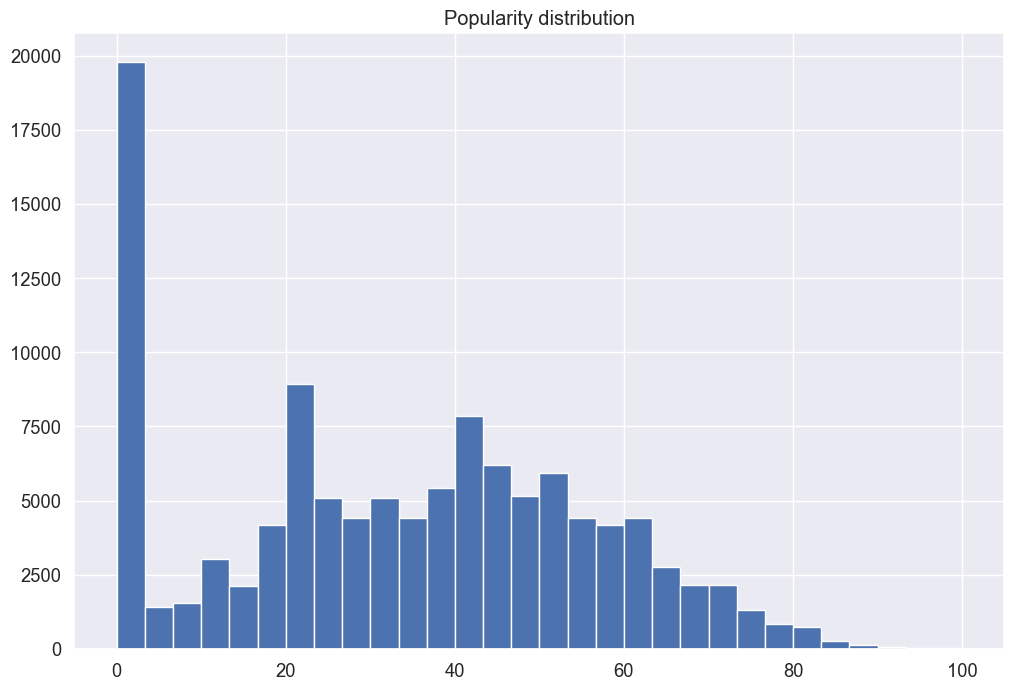

In [168]:
plt.hist(df["popularity"], bins=30)
plt.title("Popularity distribution")
plt.show()

In [176]:
numeric_cols = df.select_dtypes(include="number").columns

print(numeric_cols)

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'duration_min',
       'energy_dance', 'genre_label', 'genre_target_encoded'],
      dtype='object')


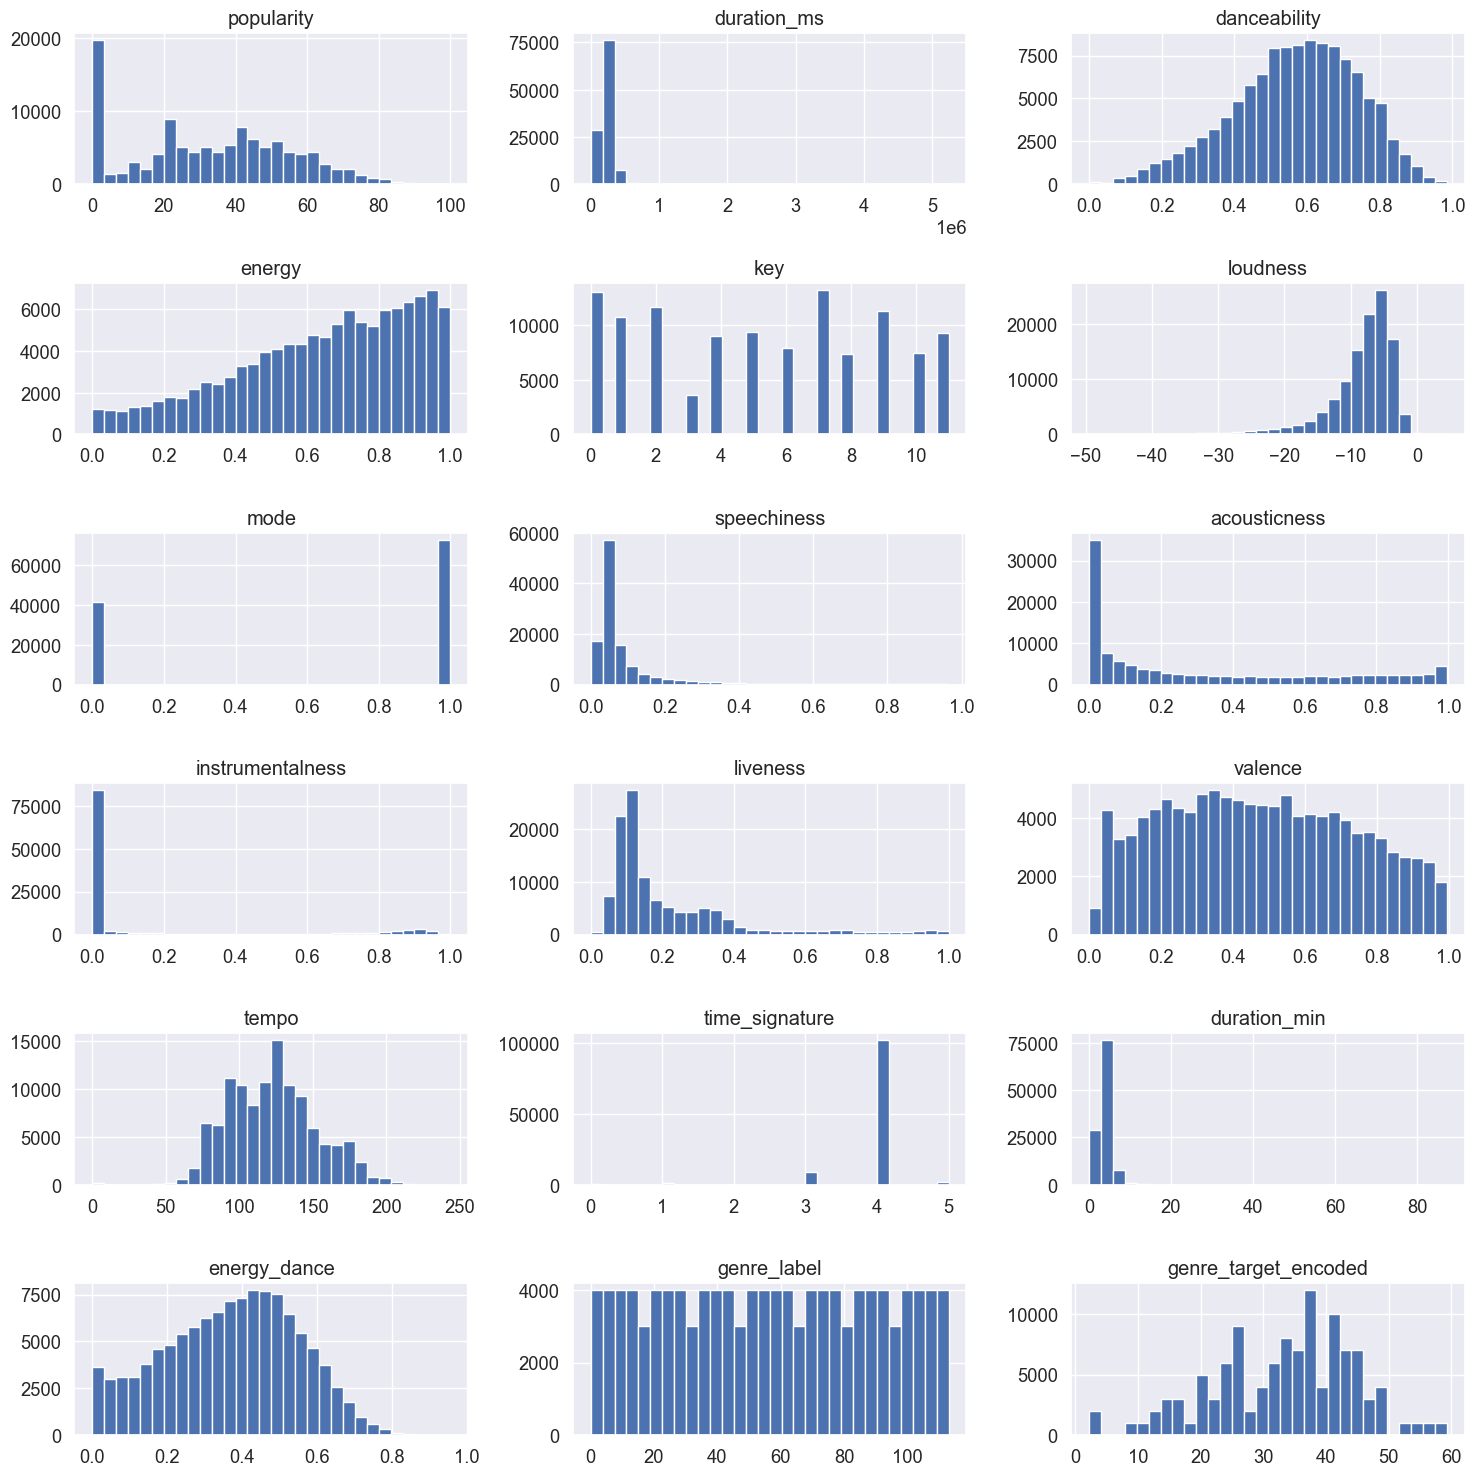

In [180]:
n_cols = 3
n_rows = (len(numeric_cols) + 2) // 3

plt.figure(figsize=(15, 15))

for i, col in enumerate(numeric_cols):
    
    plt.subplot(n_rows, n_cols, i+1)
    plt.hist(df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()